In [1]:
import dask
from dask.distributed import Client
from dask.distributed import SSHCluster
from dask.distributed import LocalCluster 
from dask.delayed import delayed
import dask.dataframe as dd 
import dask.array as da
import dask.bag as d
import graphviz

import pandas as pd
import numpy as np
import itertools
from time import time
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as patches
warnings.filterwarnings("ignore")

In [2]:
n_workers = 2
nthreads  = 2


cluster = SSHCluster(
    ["10.67.22.48", "10.67.22.48", "10.67.22.229", "10.67.22.45"],
    worker_options={"nthreads": nthreads, "n_workers": n_workers},
    scheduler_options={"port":0, "dashboard_address": ":40973"},
    connect_options={
    "known_hosts": None,
    "client_keys": "cluster_key"})

client = Client(cluster, timeout='180s')
#client = Client(cluster,'dask-scheduler:8787')


2025-08-18 19:14:40,936 - distributed.deploy.ssh - INFO - 2025-08-18 19:14:40,935 - distributed.http.proxy - INFO - To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
2025-08-18 19:14:40,938 - distributed.deploy.ssh - INFO - /home/ubuntu/.local/lib/python3.10/site-packages/distributed/node.py:187: UserWarning: Port 40973 is already in use.
2025-08-18 19:14:40,939 - distributed.deploy.ssh - INFO - Perhaps you already have a cluster running?
2025-08-18 19:14:40,940 - distributed.deploy.ssh - INFO - Hosting the HTTP server on port 33303 instead
2025-08-18 19:14:40,940 - distributed.deploy.ssh - INFO - warnings.warn(
2025-08-18 19:14:40,964 - distributed.deploy.ssh - INFO - 2025-08-18 19:14:40,964 - distributed.scheduler - INFO - State start
2025-08-18 19:14:40,972 - distributed.deploy.ssh - INFO - 2025-08-18 19:14:40,972 - distributed.scheduler - INFO -   Scheduler at:   tcp://10.67.22.48:37667
2025-08-18 19:14:42,302

In [3]:
client

<Client: 'tcp://10.67.22.48:37667' processes=5 threads=10, memory=19.43 GiB>

In [4]:
print(client.dashboard_link)
print(client.scheduler_info()["address"])
print(client.scheduler_info()["services"])
##porta per fowarding della dashboard, ora fissata a 40973

http://10.67.22.48:33303/status
tcp://10.67.22.48:37667
{'dashboard': 33303}


In [5]:
client.scheduler_info()['workers'].keys()

dict_keys(['tcp://10.67.22.229:44197', 'tcp://10.67.22.229:46671', 'tcp://10.67.22.45:36695', 'tcp://10.67.22.45:38049', 'tcp://10.67.22.48:40003'])

In [6]:
## >> xx selects rotates bits to the right by xx places
@dask.delayed
def bites_converter(block): 
    # organize in numpy arrays of 64 bits
    byte_array = np.frombuffer(block, dtype=np.uint64)
    
    # bit masking
    head = (byte_array >> 61) & 0x7         # select bits 61–63 (3 bits)
    fpga = (byte_array >> 58) & 0x7         # select bits 58–60 (3 bits)
    chan = (byte_array >> 49) & 0x1FF       # select bits 49–57 (9 bits)
    orbit = (byte_array >> 17) & 0xFFFFFFFF  # select bits 17–48 (32 bits)
    bx = (byte_array >> 5) & 0xFFF        # select bits 5–16 (12 bits)
    tdc = (byte_array >> 0) & 0x1F         # select bits 0–4 (5 bits)
    
    # we are only interested in data with head==2 
    df = pd.DataFrame(
    {"FPGA": fpga[head==2],
    "CHAN": chan[head==2],
    "ORBIT": orbit[head==2],
    "BX": bx[head==2],
    "TDC": tdc[head==2]} )
    
    return(df)

In [7]:
def read_file(file):

    client_kwargs={
        "endpoint_url": "https://cloud-areapd.pd.infn.it:5210", "verify": False}

    # small is a small bytes object from the start of the first file (to infer format), block is a list of Dask delayed objects, representing chunks of bytes from a file
    small, blocks = dask.bytes.read_bytes(
            file,
            key="32b22133696b4aad9a2872435d392277",
            secret="d2111717321d4f7dbd6755b98e95e713",
            client_kwargs=client_kwargs)  
    
    dfs = [dask.delayed(bites_converter)(block[0]) for block in blocks] # apply converter to each block lazily (each block object is a tuple, so i select [0])
    # converts a list of Dask delayed objects (chunks of a DataFrame) into a unique Dask DataFrame
    ddf = dd.from_delayed(dfs)
    return(ddf)

In [8]:
# This fuction:
# - filters events with a single scintillator hit per orbit (in order to be able to identify a unique t_0)
# - assigns the chamber number to each event
# - consider only events with more than 4 and less than num_hits chamber hits per orbit (4 are usually needed to pass the 4 detector layers, if less it is very likely noise) 
# - calculates relative time between the chamber hits and the scintillator hits to determine the drift time
#@dask.delayed
def first_processing(df,num_hits):
    
    # select scintillator hits
    scintillator = df[(df["FPGA"]==1) & (df["CHAN"]==128)].copy()
    scintillator = scintillator[["ORBIT", "BX", "TDC"]]
    scintillator["t_0"] = 25*(scintillator["ORBIT"]*3564 + scintillator["BX"] + scintillator["TDC"]/30)

    # count scintillator hits per ORBIT
    scint_counts = scintillator.groupby("ORBIT").size().to_frame("scint_hits").reset_index()
    # keep only ORBITs with a single scintillator hit
    valid_orbits = scint_counts[scint_counts["scint_hits"] == 1]["ORBIT"]
    
 
    df = df[df["CHAN"]<=127] # remove info about the scintillator

    # assign chamber number
    df = df.assign(CHAMBER = -1)
    df["CHAMBER"] = df["CHAMBER"].mask((df["FPGA"] == 0) & (df["CHAN"] <= 63), 0)
    df["CHAMBER"] = df["CHAMBER"].mask((df["FPGA"] == 0) & (df["CHAN"] > 63), 1)
    df["CHAMBER"] = df["CHAMBER"].mask((df["FPGA"] == 1) & (df["CHAN"] <= 63), 2)
    df["CHAMBER"] = df["CHAMBER"].mask((df["FPGA"] == 1) & (df["CHAN"] > 63), 3)

    # scintilattor time offset correction, per chamber
    df = df.assign(time_offset = 0.0)
    df["time_offset"] = df["time_offset"].mask(df["CHAMBER"] == 0, 95.0-1.1)
    df["time_offset"] = df["time_offset"].mask(df["CHAMBER"] == 1, 95.0+6.4)
    df["time_offset"] = df["time_offset"].mask(df["CHAMBER"] == 2, 95.0+0.5)
    df["time_offset"] = df["time_offset"].mask(df["CHAMBER"] == 3, 95.0-2.6)
    
    df["T_HIT"] = 25*(df["ORBIT"]*3564 + df["BX"] + df["TDC"]/30)
    
    # filter scintillator hits and main df: keep only events with 1 scintillator hit per ORBIT
    scintillator = scintillator[scintillator["ORBIT"].isin(valid_orbits)]
    df = df[df["ORBIT"].isin(valid_orbits)]

    # consider only events with ≤ num_hits chamber hits per ORBIT (avoid overcrowded events)
    chamber_counts = df.groupby("ORBIT").size().to_frame("hits_count").reset_index()
    valid_orbits = chamber_counts[(chamber_counts["hits_count"]<=num_hits)&(chamber_counts["hits_count"]>=4)][["ORBIT"]]
    df = df[df["ORBIT"].isin(valid_orbits["ORBIT"])]

    t0_df = scintillator[["ORBIT", "t_0"]]  # only 1 scint hit per ORBIT guaranteed here
   
    # merge t₀_df with df
    df = df.merge(t0_df, on="ORBIT", how="left") 
    
    # calculate relative chamber hit times
    df["T_REL"] = df["T_HIT"] - (df["t_0"]-df["time_offset"])
    
    return(df)    

In [9]:
# compute x and z coordinates of the chamber hits (left and right ambiguity for the x coordinate in each hit)
#@dask.delayed
def compute_coordinates(df):
    
    df["x"]=-7.5*42.0 # center of the first cell to the left in each chamber
    df["z"]=0

    # assign the z-position of the center of each chamber wrt to the floor
    df["z"]=df["z"].mask(df["CHAMBER"]==0,219.8)
    df["z"]=df["z"].mask(df["CHAMBER"]==1,977.3)
    df["z"]=df["z"].mask(df["CHAMBER"]==2,1035.6)
    df["z"]=df["z"].mask(df["CHAMBER"]==3,1819.8)

    df["CHAN_LOCAL"] = df["CHAN"]
    df["CHAN_LOCAL"] = df["CHAN_LOCAL"].mask(df["CHAMBER"].isin([1,3]), df["CHAN"]- 64) 

    layer_map = [3, 1, 2, 0]
    df["layer"] = df["CHAN_LOCAL"]%4
    df["layer"] = df["layer"].map({i: layer_map[i] for i in range(4)})

    df["x"]= df["x"] + df["CHAN_LOCAL"]// 2 * 21.
    df["z"]= df["z"] - 26.0 + (df["layer"]+0.5)*13.

    df["drift"]= df["T_REL"]*53.8*0.001
    df = df[(df["drift"]>=0)&(df["drift"]<=21.)] # drift can be at most half of the cell, discard other events (meaningless)
    
    df["X_RIGHT"]= df["x"]+df["drift"] 
    df["X_LEFT"]= df["x"]-df["drift"]

    return(df)

In [10]:
df = read_file("s3://project-bkp/data_00000*") # use all files

In [11]:
df.npartitions

10

In [12]:
df.map_partitions(len).compute() # number of rows in each partition

0    1239940
0    1243176
0    1243816
0    1243252
0    1242676
0    1242348
0    1243244
0    1241716
0    1243108
0    1244404
dtype: int64

In [13]:
df = df.map_partitions(first_processing,num_hits=25)

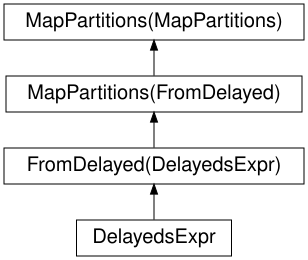

In [14]:
new_df = df.map_partitions(compute_coordinates)
new_df.visualize(filename="graph.png")

#new_df.columns = [str(c) for c in new_df.columns]
#new_df.visualize(filename="transpose_opt.svg", optimize_graph=True)

In [15]:
%%time
new_df.compute()

CPU times: user 24.9 ms, sys: 8.46 ms, total: 33.4 ms
Wall time: 2.59 s


,FPGA,CHAN,ORBIT,BX,TDC,CHAMBER,time_offset,T_HIT,t_0,T_REL,x,z,CHAN_LOCAL,layer,drift,X_RIGHT,X_LEFT
0,1,91,1118948,878,27,3,92.4,9.969829e+10,9.969829e+10,34.066666,-42.0,1800.3,27,0,1.832787,-40.167213,-43.832787
1,0,107,1118948,882,8,1,101.4,9.969829e+10,9.969829e+10,127.233337,126.0,957.8,43,0,6.845154,132.845154,119.154846
2,1,47,1118948,881,18,2,95.5,9.969829e+10,9.969829e+10,104.666672,168.0,1016.1,47,0,5.631067,173.631067,162.368933
3,1,88,1118948,884,12,3,92.4,9.969829e+10,9.969829e+10,171.566666,-63.0,1839.3,24,3,9.230287,-53.769713,-72.230287
4,1,44,1118948,881,14,2,95.5,9.969829e+10,9.969829e+10,101.333344,147.0,1055.1,44,3,5.451734,152.451734,141.548266
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7659,0,108,48580108,3047,25,1,101.4,4.328488e+12,4.328488e+12,282.233398,147.0,996.8,44,3,15.184157,162.184157,131.815843
7660,0,105,48580108,3048,22,1,101.4,4.328488e+12,4.328488e+12,304.733398,105.0,970.8,41,1,16.394657,121.394657,88.605343
7661,1,40,48580108,3046,13,2,95.5,4.328488e+12,4.328488e+12,241.333008,105.0,1055.1,40,3,12.983716,117.983716,92.016284
7662,1,38,48580108,3047,1,2,95.5,4.328488e+12,4.328488e+12,256.333008,84.0,1042.1,38,2,13.790716,97.790716,70.209284


In [16]:
# persist results to continue
df = compute_coordinates(df).persist()

<Axes: >

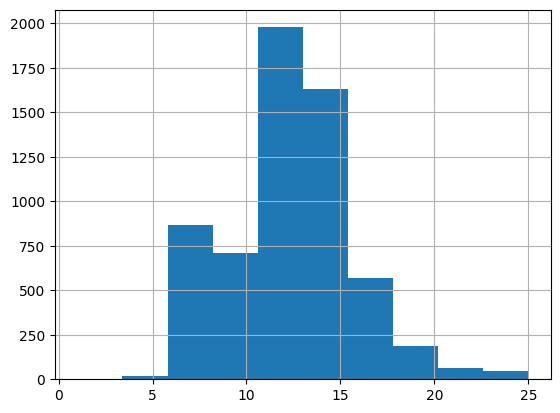

In [17]:
df.groupby("ORBIT").size().compute().hist()

## Prova del plot locale

In [18]:
# per fare le prove con diverse orbite
unique_orbits = df["ORBIT"].unique().compute()
print(unique_orbits)

0       1144838
1       1150842
2       1247112
3       1252229
4       1339251
         ...   
586    48519213
587    48520227
588    48545828
589    48569403
590    48576415
Name: ORBIT, Length: 6068, dtype: uint64


In [19]:
# per prova considero il primo valore di orbit
orbit_id = df["ORBIT"].head(1).iloc[0]
print(f"Selected orbit: {orbit_id}")

# filtro per l'orbita in questione
df_evt = df[df["ORBIT"] == 1118948].compute()
df_evt

Selected orbit: 1118948


,FPGA,CHAN,ORBIT,BX,TDC,CHAMBER,time_offset,T_HIT,t_0,T_REL,x,z,CHAN_LOCAL,layer,drift,X_RIGHT,X_LEFT
0,1,91,1118948,878,27,3,92.4,9.969829e+10,9.969829e+10,34.066666,-42.0,1800.3,27,0,1.832787,-40.167213,-43.832787
1,0,107,1118948,882,8,1,101.4,9.969829e+10,9.969829e+10,127.233337,126.0,957.8,43,0,6.845154,132.845154,119.154846
2,1,47,1118948,881,18,2,95.5,9.969829e+10,9.969829e+10,104.666672,168.0,1016.1,47,0,5.631067,173.631067,162.368933
3,1,88,1118948,884,12,3,92.4,9.969829e+10,9.969829e+10,171.566666,-63.0,1839.3,24,3,9.230287,-53.769713,-72.230287
4,1,44,1118948,881,14,2,95.5,9.969829e+10,9.969829e+10,101.333344,147.0,1055.1,44,3,5.451734,152.451734,141.548266
5,1,90,1118948,883,17,3,92.4,9.969829e+10,9.969829e+10,150.733337,-42.0,1826.3,26,2,8.109454,-33.890546,-50.109454
6,1,46,1118948,887,5,2,95.5,9.969829e+10,9.969829e+10,243.833328,168.0,1042.1,46,2,13.118233,181.118233,154.881767
7,1,89,1118948,889,12,3,92.4,9.969829e+10,9.969829e+10,296.566666,-63.0,1813.3,25,1,15.955287,-47.044713,-78.955287
8,0,105,1118948,890,20,1,101.4,9.969829e+10,9.969829e+10,337.233322,105.0,970.8,41,1,18.143153,123.143153,86.856847
9,0,108,1118948,891,13,1,101.4,9.969829e+10,9.969829e+10,356.399994,147.0,996.8,44,3,19.174320,166.174320,127.825680


Per questo plot locale non ho usato la vera coordinata z ma una coordinata "fittizia" y per comodità (nel plot globale converrà usare la z).

In [20]:
def plot_chamber_hits(df_evt, chamber_id=3):
    # filters the selected chamber
    df_ch = df_evt[df_evt["CHAMBER"] == chamber_id]
    
    n_layers = 4
    n_cells = 16
    cell_w = 42.0  # mm
    cell_h = 13.0  # mm
    offset = cell_w / 2
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # for the cells
    for layer in range(n_layers):
        # offset for odd layers
        x_offset = 0 if layer % 2 == 0 else offset
        for cell in range(n_cells):
            x0 = (cell * cell_w) - (n_cells * cell_w) / 2 + x_offset
            y0 = (n_layers - layer - 1) * cell_h
            rect = patches.Rectangle(
                (x0, y0),
                cell_w, cell_h,
                linewidth=2, edgecolor="gray", facecolor="none"
            )
            ax.add_patch(rect)
            
    layer_order = {0: 0, 2: 1, 1: 2, 3: 3} # mapping for the y (1-2 are inverted)
    y_pos = (n_layers - 1 - df_ch["layer"].map(layer_order))

    ax.scatter(df_ch["x"], 
               y_pos * cell_h + cell_h / 2,
               color="red", s=2, zorder=3, label="Center")
    
    ax.scatter(df_ch["X_LEFT"], 
               y_pos * cell_h + cell_h / 2,
               color="blue", s=2, marker='x', zorder=3, label="Left")
    
    ax.scatter(df_ch["X_RIGHT"], 
               y_pos * cell_h + cell_h / 2,
               color="blue", s=2, marker='x', zorder=3, label="Right")

    ax.set_aspect('equal')
    ax.set_xlabel("x [mm]")
    ax.set_ylabel("")
    ax.set_title(f"Chamber {chamber_id}")
    #ax.legend()
    plt.show()

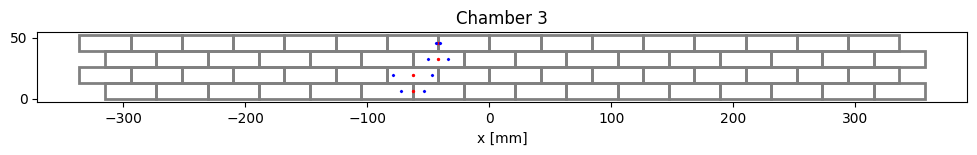

In [21]:
plot_chamber_hits(df_evt, chamber_id=3)

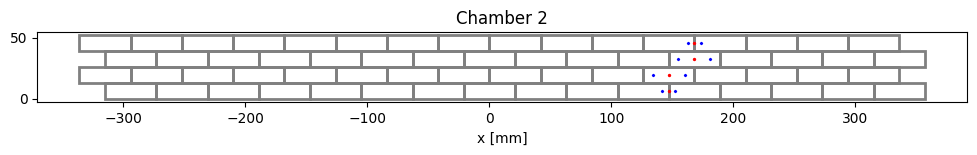

In [22]:
plot_chamber_hits(df_evt, chamber_id=2)

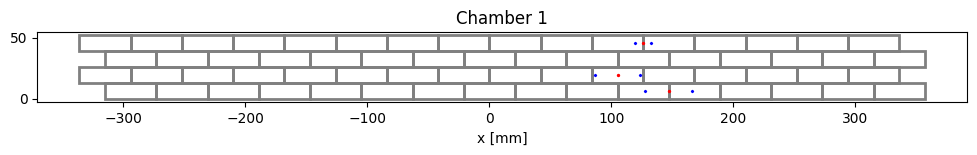

In [23]:
plot_chamber_hits(df_evt, chamber_id=1)

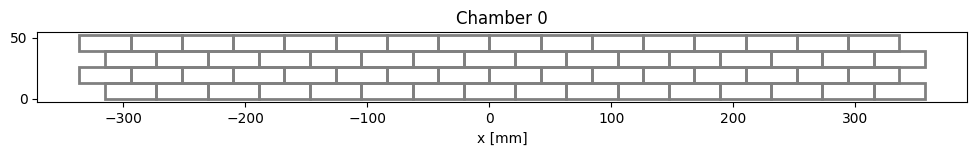

In [24]:
plot_chamber_hits(df_evt, chamber_id=0)

## Prova del fit locale - prova

In [25]:
def fit_local_geom(df_evt, chamber_id=3, cell_h=13.0):
    df_ch = df_evt[df_evt["CHAMBER"] == chamber_id].copy()
    if len(df_ch) < 3:
        return None

    layer_order = {0: 0, 2: 1, 1: 2, 3: 3}
    y_pos = (3 - df_ch["layer"].map(layer_order))
    y_vals = y_pos.values * cell_h + cell_h/2.0
    
    x_left  = df_ch["X_LEFT"].values
    x_right = df_ch["X_RIGHT"].values

    best = {"resid": np.inf}
    for choice in itertools.product([0, 1], repeat=len(y_vals)):
        x_vals = np.where(np.array(choice) == 0, x_left, x_right)
        m, q = np.polyfit(y_vals, x_vals, 1)
        resid = np.sum((x_vals - (m*y_vals + q))**2)
        
        if resid < best["resid"]:
            best = {
                "m": m, "q": q, "resid": resid,
                "x_best": x_vals.copy(), "y_vals": y_vals.copy()
            }
    return best

In [26]:
def fit_chamber_hits(df_evt, chamber_id=3):
    # filters the selected chamber
    df_ch = df_evt[df_evt["CHAMBER"] == chamber_id]
    
    n_layers = 4
    n_cells = 16
    cell_w = 42.0  # mm
    cell_h = 13.0  # mm
    offset = cell_w / 2
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # for the cells
    for layer in range(n_layers):
        # offset for odd layers
        x_offset = 0 if layer % 2 == 0 else offset
        for cell in range(n_cells):
            x0 = (cell * cell_w) - (n_cells * cell_w) / 2 + x_offset
            y0 = (n_layers - layer - 1) * cell_h
            rect = patches.Rectangle(
                (x0, y0),
                cell_w, cell_h,
                linewidth=2, edgecolor="gray", facecolor="none"
            )
            ax.add_patch(rect)
            
    layer_order = {0: 0, 2: 1, 1: 2, 3: 3} # mapping for the y (1-2 are inverted)
    y_pos = (n_layers - 1 - df_ch["layer"].map(layer_order))

    ax.scatter(df_ch["x"], 
               y_pos * cell_h + cell_h / 2,
               color="red", s=2, zorder=3, label="Center")
    
    ax.scatter(df_ch["X_LEFT"], 
               y_pos * cell_h + cell_h / 2,
               color="blue", s=2, marker='x', zorder=3, label="Left")
    
    ax.scatter(df_ch["X_RIGHT"], 
               y_pos * cell_h + cell_h / 2,
               color="blue", s=2, marker='x', zorder=3, label="Right")
    res = fit_local_geom(df_evt, chamber_id=3)
    if res is not None:
        m, q = res["m"], res["q"]
        y_line = np.linspace(0, 4*cell_h, 100)
        x_line = m*y_line + q
        ax.plot(x_line, y_line, color="black", linewidth=2, label="Fit")


    ax.set_aspect('equal')
    ax.set_xlabel("x [mm]")
    ax.set_ylabel("")
    ax.set_title(f"Chamber {chamber_id}")
    #ax.legend()
    plt.show()

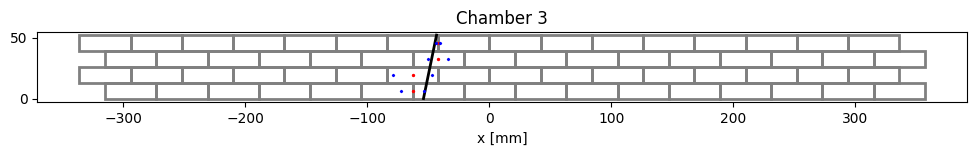

In [27]:
fit_chamber_hits(df_evt, chamber_id=3)

# Due metodi per generalizzare (groupby+apply e group_by+map_partition )

## Versione senza chi2

### Groupby+apply

In [50]:
layer_order = {0: 0, 2: 1, 1: 2, 3: 3}

def fit_local_geom_pandas(df_evt, cell_h=13.0):
    if len(df_evt) < 3:
        return pd.Series({"m": np.nan, "q": np.nan, "resid": np.nan})
    
    y_pos = (3 - df_evt["layer"].map(layer_order))
    y_vals = y_pos.values * cell_h + cell_h/2.0
    
    x_left  = df_evt["X_LEFT"].values
    x_right = df_evt["X_RIGHT"].values

    best = {"resid": np.inf}
    for choice in itertools.product([0, 1], repeat=len(y_vals)):
        x_vals = np.where(np.array(choice) == 0, x_left, x_right)
        m, q = np.polyfit(y_vals, x_vals, 1)
        resid = np.sum((x_vals - (m*y_vals + q))**2)
        if resid < best["resid"]:
            best = {"m": m, "q": q, "resid": resid}

    return pd.Series(best)



In [51]:
df_fits_1 = (
    new_df.groupby(["ORBIT", "CHAMBER"])
    .apply(fit_local_geom_pandas)#, meta={"m": "f8", "q": "f8", "resid": "f8"})
)

In [52]:
%%time
df_fits_1.compute()


CPU times: user 59.2 ms, sys: 4.59 ms, total: 63.8 ms
Wall time: 35.5 s


m           q       resid
ORBIT    CHAMBER                                  
1144838  0       -0.010397   92.035694    0.252763
         1        0.059809  144.108784    0.120400
         2       -0.015107  129.282335    0.665407
         3        0.128295  164.536371    0.113438
1150842  1       -0.281894  251.450327  694.010230
...                    ...         ...         ...
48569403 1       -0.088631  120.907328    0.020815
         2       -0.306592  172.875638   32.347594
48576415 1        0.203547   84.257860  226.488610
         2        0.212441   97.983574   17.277284
         3        0.149182  -91.698551   12.346652

[19084 rows x 3 columns]

### map_partitions+groupby

In [53]:
layer_order = {0: 0, 2: 1, 1: 2, 3: 3}

def fit_local_geom_pandas(df_evt, cell_h=13.0):
    if len(df_evt) < 3:
        return pd.Series({"m": np.nan, "q": np.nan, "resid": np.nan})
    
    y_pos = (3 - df_evt["layer"].map(layer_order))
    y_vals = y_pos.values * cell_h + cell_h/2.0
    
    x_left  = df_evt["X_LEFT"].values
    x_right = df_evt["X_RIGHT"].values

    best = {"resid": np.inf}
    for choice in itertools.product([0, 1], repeat=len(y_vals)):
        x_vals = np.where(np.array(choice) == 0, x_left, x_right)
        m, q = np.polyfit(y_vals, x_vals, 1)
        resid = np.sum((x_vals - (m*y_vals + q))**2)
        if resid < best["resid"]:
            best = {"m": m, "q": q, "resid": resid}

    return pd.Series(best)


def fit_partition(df, cell_h=13.0):
    results = []
    for (orbit, chamber), df_grp in df.groupby(["ORBIT", "CHAMBER"]):
        res = fit_local_geom_pandas(df_grp, cell_h=cell_h)
        res["ORBIT"] = orbit  
        res["CHAMBER"] = chamber  
        results.append(res)
    
    df_out = pd.DataFrame(results)
    return df_out.set_index(["ORBIT", "CHAMBER"])


In [54]:
df_fits_2 = new_df.map_partitions(
    fit_partition, 
    meta={"m": "f8", "q": "f8", "resid": "f8"}
)


In [55]:
%%time
df_fits_2.compute()


CPU times: user 47.7 ms, sys: 250 μs, total: 48 ms
Wall time: 39.6 s


m           q       resid
ORBIT      CHAMBER                                  
1118948.0  1.0     -0.212482  128.438703    2.064959
           2.0      0.189957  152.471441   31.471888
           3.0      0.205739  -54.038375   18.350290
1123056.0  0.0     -0.127314  127.535210    1.940395
           1.0     -0.357688  171.153693   47.318154
...                      ...         ...         ...
48576415.0 1.0      0.203547   84.257860  226.488610
           2.0      0.212441   97.983574   17.277284
           3.0      0.149182  -91.698551   12.346652
48580108.0 1.0     -0.180950  129.764483   36.459432
           2.0      0.290037   91.942290   37.163278

[19084 rows x 3 columns]

## Versione con Chi2

### Groupby+apply

In [58]:
layer_order = {0: 0, 2: 1, 1: 2, 3: 3} ###porto fuori perchè dentro non serve e sembra più veloce

def fit_local_geom_pandas(df_evt, cell_h=13.0):
    if len(df_evt) < 3:
        return pd.Series({"m": np.nan, "q": np.nan, "resid": np.nan, "χ²/ndof": np.nan})
    
    y_pos = (3 - df_evt["layer"].map(layer_order))
    y_vals = y_pos.values * cell_h + cell_h/2.0
    
    x_left  = df_evt["X_LEFT"].values
    x_right = df_evt["X_RIGHT"].values
    sigma=1
    best = {"resid": np.inf, "χ²/ndof": np.inf}

    for choice in itertools.product([0, 1], repeat=len(y_vals)):
        x_vals = np.where(np.array(choice) == 0, x_left, x_right)
        m, q = np.polyfit(y_vals, x_vals, 1)
        
        residuals = (x_vals - (m*y_vals + q))**2
        resid = np.sum(residuals) ####  sum here so I can use residuals in chi2 without "breaking up" the sum
        chi2 = np.sum((residuals / sigma))  ##already squared
        ndof = len(x_vals) - 2  # 2=number of parameters of linear fit

        if chi2/ndof < best["χ²/ndof"]:
            best = {"m": m, "q": q, "resid": resid, "χ²/ndof": chi2/ndof}

    return pd.Series(best)
df_fits_1 = (
    new_df.groupby(["ORBIT", "CHAMBER"])
    .apply(fit_local_geom_pandas)#, meta={"m": "f8", "q": "f8", "resid": "f8"})
)


In [59]:
%%time
df_fits_1.compute()

CPU times: user 69.5 ms, sys: 6.49 ms, total: 76 ms
Wall time: 38.8 s


m           q       resid     χ²/ndof
ORBIT    CHAMBER                                              
1144838  0       -0.010397   92.035694    0.252763    0.252763
         1        0.059809  144.108784    0.120400    0.120400
         2       -0.015107  129.282335    0.665407    0.332704
         3        0.128295  164.536371    0.113438    0.113438
1150842  1       -0.281894  251.450327  694.010230  231.336743
...                    ...         ...         ...         ...
48569403 1       -0.088631  120.907328    0.020815    0.020815
         2       -0.306592  172.875638   32.347594   16.173797
48576415 1        0.203547   84.257860  226.488610   56.622152
         2        0.212441   97.983574   17.277284    8.638642
         3        0.149182  -91.698551   12.346652    6.173326

[19084 rows x 4 columns]

### map_partitions+groupby

In [56]:
layer_order = {0: 0, 2: 1, 1: 2, 3: 3} ###porto fuori perchè dentro non serve e sembra più veloce

def fit_local_geom_pandas(df_evt, cell_h=13.0):
    if len(df_evt) < 3:
        return pd.Series({"m": np.nan, "q": np.nan, "resid": np.nan})
    
    y_pos = (3 - df_evt["layer"].map(layer_order))
    y_vals = y_pos.values * cell_h + cell_h/2.0
    
    x_left  = df_evt["X_LEFT"].values
    x_right = df_evt["X_RIGHT"].values

    best = {"resid": np.inf, "χ²/ndof": np.inf}

    for choice in itertools.product([0, 1], repeat=len(y_vals)):
        x_vals = np.where(np.array(choice) == 0, x_left, x_right)
        m, q = np.polyfit(y_vals, x_vals, 1)
        sigma=1
        residuals = (x_vals - (m*y_vals + q))**2
        resid = np.sum(residuals) ####  sum here so I can use residuals in chi2 without "breaking up" the sum
        chi2 = np.sum((residuals / sigma))  ##already squared
        ndof = len(x_vals) - 2  # 2=number of parameters of linear fit

        if chi2/ndof < best["χ²/ndof"]:
            best = {"m": m, "q": q, "resid": resid, "χ²/ndof": chi2/ndof}
    return pd.Series(best)


def fit_partition(df, cell_h=13.0):
    results = []
    for (orbit, chamber), df_grp in df.groupby(["ORBIT", "CHAMBER"]):
        res = fit_local_geom_pandas(df_grp, cell_h=cell_h)
        res["ORBIT"] = orbit  
        res["CHAMBER"] = chamber  
        results.append(res)
    
    df_out = pd.DataFrame(results)
    return df_out.set_index(["ORBIT", "CHAMBER"])
    
df_fits_2 = new_df.map_partitions(
    fit_partition, 
    meta={"m": "f8", "q": "f8", "resid": "f8","χ²/ndof": "f8"}
)
    

In [57]:
%%time
df_fits_2.compute()

CPU times: user 59.8 ms, sys: 9.11 ms, total: 68.9 ms
Wall time: 41.4 s


m           q       resid    χ²/ndof
ORBIT      CHAMBER                                             
1118948.0  1.0     -0.212482  128.438703    2.064959   2.064959
           2.0      0.189957  152.471441   31.471888  15.735944
           3.0      0.205739  -54.038375   18.350290   9.175145
1123056.0  0.0     -0.127314  127.535210    1.940395   0.970197
           1.0     -0.357688  171.153693   47.318154  23.659077
...                      ...         ...         ...        ...
48576415.0 1.0      0.203547   84.257860  226.488610  56.622152
           2.0      0.212441   97.983574   17.277284   8.638642
           3.0      0.149182  -91.698551   12.346652   6.173326
48580108.0 1.0     -0.180950  129.764483   36.459432  36.459432
           2.0      0.290037   91.942290   37.163278  18.581639

[19084 rows x 4 columns]